In [ ]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [ ]:
import requests
import io
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/madmanor/lis4893/refs/heads/main/lab5/covid-metadata.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

In [ ]:
df = pd.read_csv(io.StringIO(response.text))

In [ ]:
# TASK 2: Display first 10
df.head(10)

,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-006-809-764-724,Awareness level of doctors regarding corona vi...,2020-10-02,2020.0,journal article,Journal of Medical Sciences,NaN,NaN,NaN,Iqbal Haider; Aliena Badshah; Ismail Tajik; Za...,...,NaN,NaN,3093127064,NaN,0,NaN,0,False,NaN,NaN
1,000-128-384-338-433,Follow-up of caregivers involved in the manage...,2020-07-12,2020.0,journal article,Bulletin de l'Academie nationale de medecine,00014079,Elsevier Masson SAS,Netherlands,NaN,...,32836273.0,10.1016/j.banm.2020.07.008,NaN,PMC7354267,0,NaN,0,True,NaN,green
2,000-144-858-759-943,"Kesehatan Mental, Perilaku, dan Stigma COVID-1...",2020-12-30,2020.0,NaN,NaN,NaN,NaN,NaN,Leny Latifah,...,NaN,NaN,3114505788,NaN,0,NaN,0,False,NaN,NaN
3,000-202-305-057-119,Bireylerin Covid-19 Korkularının Bazı Değişken...,2021-06-21,2021.0,journal article,Humanistic Perspective,26874229,Humanistic Perspective,NaN,Mehmet Rüştü Kalafatoğlu; Faruk Caner Yam,...,NaN,10.47793/hp.942883,3173693918,NaN,0,003-608-628-045-947; 004-040-856-284-664; 004-...,11,True,cc-by-nc,gold
4,000-352-861-219-610,Verplichte Overheidszaken Principle on the Per...,2021-11-14,2021.0,NaN,NaN,NaN,NaN,NaN,I Nyoman Prabu Buana Rumiartha,...,NaN,NaN,3213503383,NaN,0,NaN,0,False,NaN,NaN
5,000-580-620-305-029,Reactogenicity Following Receipt of mRNA-Based...,2021-06-01,2021.0,journal article,JAMA,15383598; 00987484,American Medical Association (AMA),United States,Johanna Chapin-Bardales; Julianne Gee; Tanya R...,...,33818592.0,10.1001/jama.2021.5374,3148644681,NaN,0,004-528-456-663-592; 010-249-680-462-918; 022-...,323,True,NaN,bronze
6,000-649-649-862-606,Aspek Imunitas pada COVID-19,2021-09-01,2021.0,journal article,Cermin Dunia Kedokteran,25032720; 0125913x,PT Kalbe Farma Tbk.,NaN,Nugroho Nitiyoso,...,NaN,10.55175/cdk.v48i9.1497,NaN,NaN,0,NaN,0,False,NaN,NaN
7,000-874-593-776-979,Mitigation Policies and COVID-19-Associated Mo...,2021-01-15,2021.0,journal article,MMWR. Morbidity and mortality weekly report,1545861x; 01492195,Centers for Disease Control MMWR Office,United States,James A. Fuller; Avi J Hakim; Kerton R. Victor...,...,33443494.0,10.15585/mmwr.mm7002e4,3119260112,PMC7808713,0,008-940-877-684-906; 012-644-173-152-475; 013-...,60,True,NaN,gold
8,001-083-113-541-069,Analisis Rantai Markov dalam Memprediksi Statu...,2021-05-10,2021.0,journal article,Indonesian Journal of Applied Mathematics,27742016; 27742067,Institut Teknologi Sumatra,NaN,Nabila Nurita Putri; Triyana Muliawati,...,NaN,10.35472/indojam.v1i2.352,3160226199,NaN,0,NaN,1,True,cc-by-nc,hybrid
9,001-149-158-127-24X,การมีส่วนร่วมของภาคีเครือข่าย คณะกรรมการพัฒนาค...,2024-06-08,2024.0,journal article,Interdisciplinary Academic and Research Journal,29852749,Dr. Ken Institute of Academic Development and ...,NaN,อาภากานต์ คลื่นแก้ว; อัจฉรา จินวงษ์,...,NaN,10.60027/iarj.2024.273888,NaN,NaN,0,162-552-009-012-930,0,True,cc-by-nc-nd,gold


In [ ]:
print(df.columns)

Index(['Lens ID', 'Title', 'Date Published', 'Publication Year',
       'Publication Type', 'Source Title', 'ISSNs', 'Publisher',
       'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number',
       'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms',
       'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI',
       'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References',
       'Citing Works Count', 'Is Open Access', 'Open Access License',
       'Open Access Colour'],
      dtype='object')


In [ ]:
# TASK 3: Preprocess and model
import string
import nltk
from nltk.corpus import stopwords
import gensim.corpora as corpora
from gensim.models import LdaModel

In [ ]:
# Stop words
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Custom stop words
custom_stopwords = ['abstract', 'dan', 'yang',
                    'patients', 'article', 'author', 'background', 'conclusion', 'data', 'evidence', 'finding', 'findings', 'index', 'keywords', 'methods', 'objective', 'p', 'participants', 'published', 'results', 'review', 'study', 'summary', 'supplementary', 'using','covid', 'coronavirus', 'sars', 'cov', 'pandemic', 'outbreak', 'disease', 'health', 'covid19']
# extend the list
stop_words.extend(custom_stopwords)

In [ ]:
# Cleaning function
def clean_doc(doc):
    no_punct = ''.join([c for c in doc if c not in string.punctuation])
    words = no_punct.lower().split()
    final_words = [word for word in words if word not in stop_words and not word.isdigit()]
    return final_words

In [ ]:
# Using abstract col
docs = df['Abstract'].fillna('').tolist()

# Use cleaning function on the docs
cleaned_docs = [clean_doc(doc) for doc in docs]

# Id word index
id2word = corpora.Dictionary(cleaned_docs)

# creat the bag of words
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [ ]:
# Run two LDA Models

# 10 topics
lda_model_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10, random_state=100)
# 20 topics
lda_model_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20, random_state=100)

In [ ]:
print("10 topic model")
for idx, topic in lda_model_10.print_topics(num_topics=10, num_words=5):
    print(f"Topic {idx}: {topic}")

print("20 topic model")
for idx, topic in lda_model_20.print_topics(num_topics=20, num_words=5):
    print(f"Topic {idx}: {topic}")

10 topic model
Topic 0: 0.017*"research" + 0.017*"centre" + 0.017*"elsevier" + 0.017*"resource" + 0.011*"information"
Topic 1: 0.005*"higher" + 0.004*"cases" + 0.004*"associated" + 0.004*"symptoms" + 0.004*"group"
Topic 2: 0.010*"long" + 0.006*"cases" + 0.005*"symptoms" + 0.005*"information" + 0.004*"vaccine"
Topic 3: 0.007*"infection" + 0.005*"long" + 0.005*"risk" + 0.004*"severe" + 0.003*"research"
Topic 4: 0.008*"symptoms" + 0.008*"long" + 0.005*"syndrome" + 0.005*"infection" + 0.005*"severe"
Topic 5: 0.004*"infection" + 0.004*"vaccine" + 0.004*"long" + 0.003*"mortality" + 0.003*"penelitian"
Topic 6: 0.016*"long" + 0.005*"vaccination" + 0.005*"symptoms" + 0.005*"people" + 0.004*"infection"
Topic 7: 0.009*"long" + 0.006*"symptoms" + 0.004*"positive" + 0.004*"research" + 0.004*"cases"
Topic 8: 0.005*"vaccination" + 0.005*"symptoms" + 0.005*"among" + 0.004*"risk" + 0.004*"children"
Topic 9: 0.007*"vaccine" + 0.007*"symptoms" + 0.005*"cases" + 0.005*"vaccination" + 0.004*"among"
20 topi

In [ ]:
# Noted covid19, patients, dan, yang, as a common words so added them to the custom stopword list.
# The quality of the topics seem to be mostly similar across both models, both have some noice of incoherent words. The 20 topic model has more unnessesary and reused topics compared to the 10 topic model.
# I would use the 10 topic model.


In [ ]:
id2word[25]

'complications'

In [ ]:
# TASK 4 Visualizations
import matplotlib.pyplot as plt

topic_data = []
target_topic_ids = [2, 5, 10, 15]

for topic_id in target_topic_ids:
  topic_terms = lda_model_20.show_topic(topic_id, topn = 10)

  for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })


In [ ]:
df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully.")

DataFrame 'df_topic_words' created successfully.


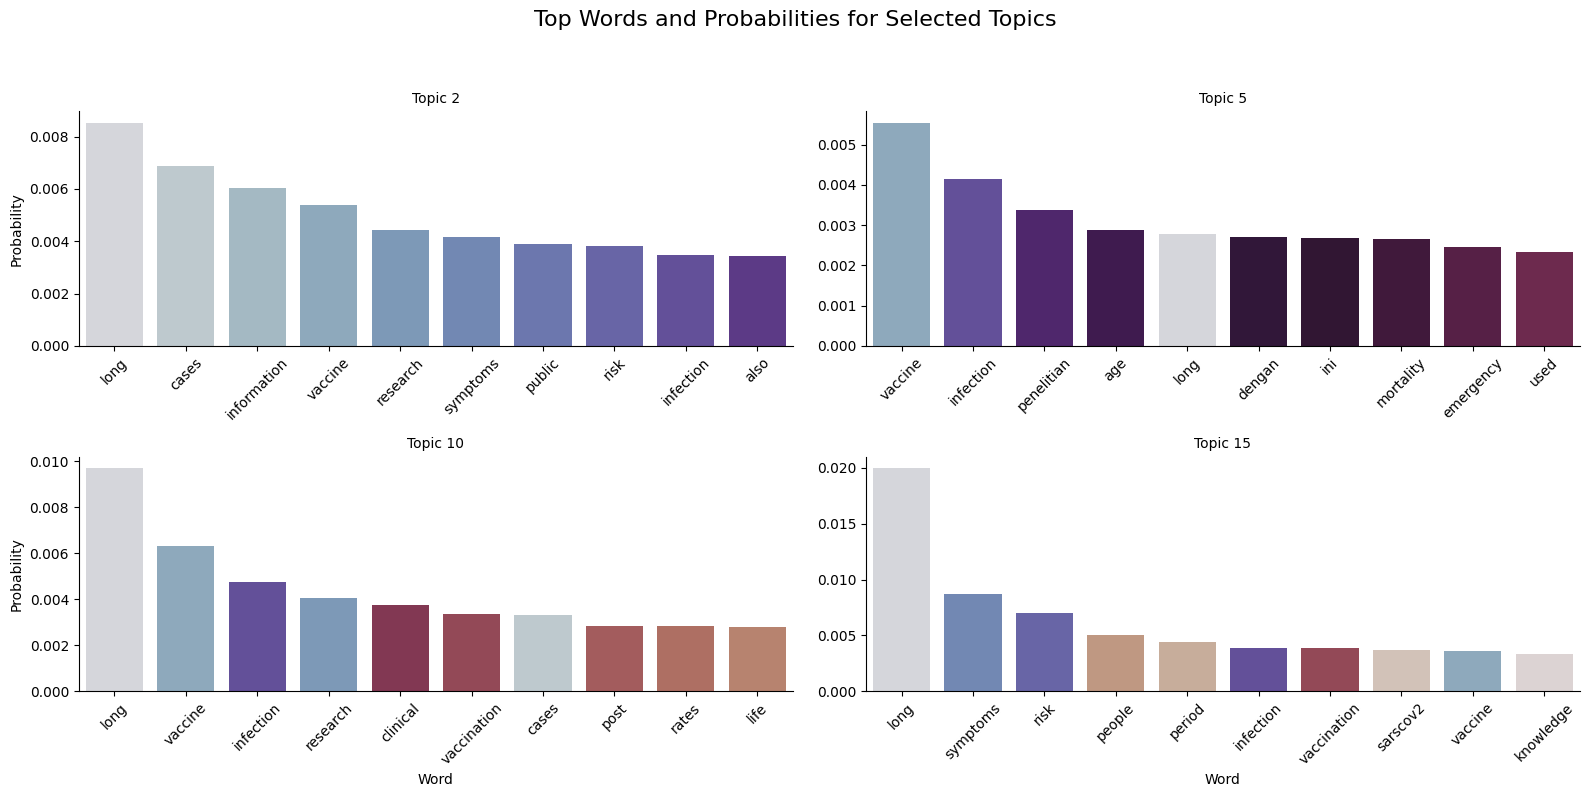

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

g = sns.catplot(
    data=df_topic_words,
    x='Word',
    y='Probability',
    col='Topic ID',
    col_wrap=2,
    kind='bar',
    height=4,
    aspect=2,
    hue='Word',
    legend=False,
    palette='twilight',
    sharex=False,
    sharey=False
)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
#Topic Labels
#Topic 2: Length of COVID Symptoms
#Topic 5: Vaccine and Infection
#Topic 10: Long Term COVID Research
#Topic 15: Specific Patient Groups and Symptoms

# Topic 5 seems to have the most distinct topics that dont appear in the other ones: age, penelitian, mortality

# Topics 2, 10 and 15 overlap the most with main words: long, vaccination.

# The top words make sense because with the dataset being COVID metadata, i would expect there to be lots of research on long term covid symtoms and correlation with vaccines.

# In the future I could see the use of applying these methods to aviation research.